# Análisis de Componentes Principales (PCA)
## Dataset: Riesgo Crediticio

**Objetivo:** Entender qué es PCA, para qué sirve, y aplicarlo al dataset de crédito.

---

### ¿Qué es PCA?

PCA es una técnica para **reducir la dimensionalidad** de un dataset manteniendo la mayor cantidad de información posible.

**Analogía simple:**  
Imagina que tienes una escultura 3D y quieres fotografiarla. Puedes tomar la foto desde mil ángulos distintos, pero hay uno que captura mejor la forma general. PCA encuentra ese "ángulo óptimo" para proyectar tus datos en menos dimensiones sin perder demasiado detalle.

---

### ¿Para qué sirve en la práctica?

| Problema | PCA como solución |
|----------|------------------|
| Muchas variables correlacionadas | Las combina en componentes independientes |
| No puedo visualizar datos de 10+ dimensiones | Reduce a 2D o 3D para graficar |
| El modelo es lento con 50 variables | Entrena con 10 componentes que capturan el 95% |
| Variables ruidosas que confunden al modelo | Elimina el ruido al quedarse con las componentes principales |

---

### Estructura de este notebook

| Sección | Contenido |
|---------|----------|
| 1 | Carga y preparación de datos |
| 2 | ¿Por qué necesitamos PCA? Correlación entre variables |
| 3 | Aplicar PCA paso a paso |
| 4 | Varianza explicada: ¿cuántos componentes necesito? |
| 5 | Visualización: clientes en 2D |
| 6 | Interpretación de componentes |
| 7 | PCA como preprocesamiento para Regresión Logística |
| 8 | Conclusiones |

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
np.random.seed(42)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## Sección 1 · Carga y preparación de datos

Usamos el mismo `train.csv` de la Tarea 2.  
Para PCA solo nos interesan las **variables numéricas** — PCA trabaja con números, no con texto.

In [20]:
df = pd.read_csv('train.csv')

print(f'Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'\nColumnas:')
print(df.dtypes.to_string())

Shape: 45,528 filas x 19 columnas

Columnas:
customer_id                    str
name                           str
age                          int64
gender                         str
owns_car                       str
owns_house                     str
no_of_children             float64
net_yearly_income          float64
no_of_days_employed        float64
occupation_type                str
total_family_members       float64
migrant_worker             float64
yearly_debt_payments       float64
credit_limit               float64
credit_limit_used(%)         int64
credit_score               float64
prev_defaults                int64
default_in_last_6months      int64
credit_card_default          int64


In [21]:
# Variables técnicas a eliminar (no aportan información al modelo)
COLS_EXCLUIR = ['customer_id', 'name']

# Variable objetivo
TARGET = 'default_in_last_6months'

# Seleccionar solo variables numéricas (excluyendo el target y columnas técnicas)
NUMERICAS = [
    'age', 'no_of_children', 'net_yearly_income', 'no_of_days_employed',
    'total_family_members', 'migrant_worker', 'yearly_debt_payments',
    'credit_limit', 'credit_limit_used(%)'
    #, 'credit_score'
    #,'prev_defaults'
]

# Filtrar variables que existan en el dataset
NUMERICAS = [c for c in NUMERICAS if c in df.columns]

print(f'Variables numéricas seleccionadas ({len(NUMERICAS)}):')
for col in NUMERICAS:
    print(f'  - {col}')

Variables numéricas seleccionadas (9):
  - age
  - no_of_children
  - net_yearly_income
  - no_of_days_employed
  - total_family_members
  - migrant_worker
  - yearly_debt_payments
  - credit_limit
  - credit_limit_used(%)


In [22]:
# Preparar X e y
X_raw = df[NUMERICAS].copy()
y     = df[TARGET].copy()

# Imputar nulos con la mediana (mismo criterio que la tarea principal)
nulos_antes = X_raw.isnull().sum().sum()
X_raw = X_raw.fillna(X_raw.median())
nulos_despues = X_raw.isnull().sum().sum()

print(f'Nulos antes: {nulos_antes}  →  después: {nulos_despues}')
print(f'\nTasa de default: {y.mean()*100:.1f}%')
print(f'Registros: {len(y):,}')

X_raw.describe().round(2)

Nulos antes: 1502  →  después: 0

Tasa de default: 5.1%
Registros: 45,528


,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%)
count,45528.00,45528.00,4.552800e+04,45528.00,45528.00,45528.00,45528.00,45528.00,45528.00
mean,38.99,0.41,2.006556e+05,66944.35,2.16,0.18,31791.30,43548.42,52.24
std,9.54,0.72,6.690740e+05,138768.42,0.91,0.38,17252.14,148784.69,29.38
min,23.00,0.00,2.717061e+04,2.00,1.00,0.00,2237.47,4003.14,0.00
25%,31.00,0.00,1.263458e+05,946.75,2.00,0.00,19240.26,23973.80,27.00
50%,39.00,0.00,1.717149e+05,2224.00,2.00,0.00,29081.65,35688.04,54.00
75%,47.00,1.00,2.406038e+05,5687.50,3.00,0.00,40535.47,53435.76,78.00
max,55.00,9.00,1.407590e+08,365252.00,10.00,1.00,328112.86,31129970.49,99.00


---
## Sección 2 · ¿Por qué necesitamos PCA?

### El problema: variables correlacionadas

Cuando dos variables dicen casi lo mismo, están **redundando información**.  
Por ejemplo: `credit_limit` y `yearly_debt_payments` probablemente están correlacionadas — clientes con mayor límite también tienen más deuda.

**Problema:**  
- El modelo recibe información duplicada
- Es difícil interpretar qué variable importa más
- En dimensiones altas, los datos se vuelven escasos ("maldición de la dimensionalidad")

**Solución PCA:**  
Combinar variables correlacionadas en nuevas variables independientes (componentes).

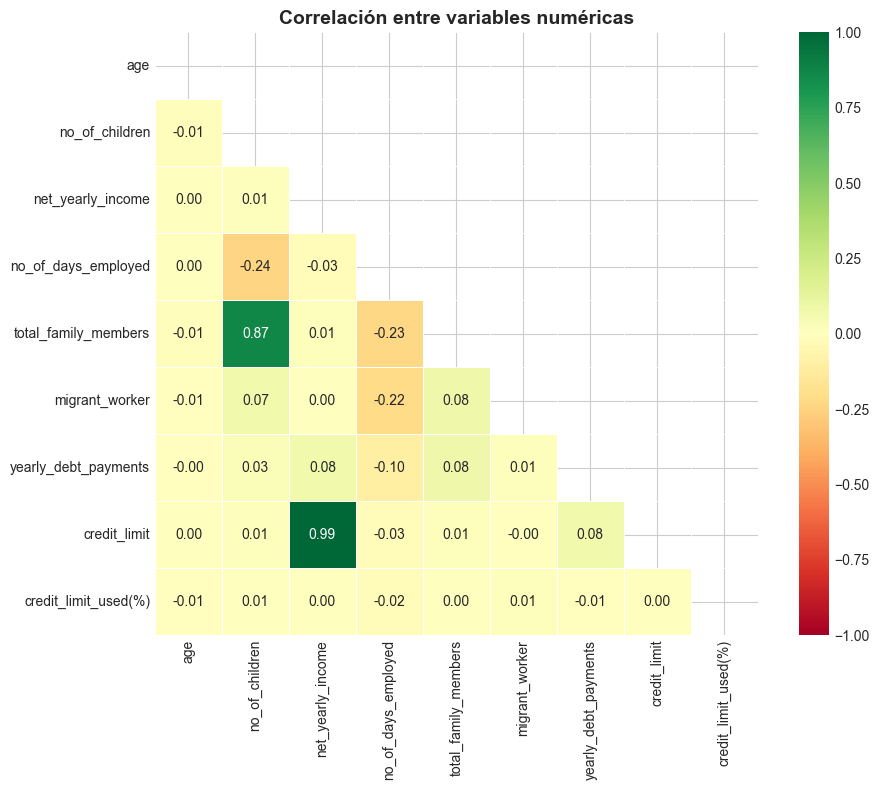

Pares con correlación > 0.4 (valores absolutos):
  no_of_children <-> total_family_members: 0.870
  net_yearly_income <-> credit_limit: 0.993


In [23]:
# Matriz de correlación entre las variables numéricas
corr_matrix = X_raw.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Correlación entre variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar pares con alta correlación
print('Pares con correlación > 0.4 (valores absolutos):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.4:
            print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_val:.3f}')

---
## Sección 3 · Aplicar PCA paso a paso

### Paso obligatorio: escalar los datos

PCA es **sensible a la escala**. Si `net_yearly_income` va de 0 a 1,000,000 y `no_of_children` va de 0 a 5, PCA va a pensar que el ingreso es más importante solo porque sus números son más grandes.

**Regla de oro:** siempre aplicar `StandardScaler` antes de PCA.  
Esto convierte cada variable a media=0 y desviación estándar=1.

In [24]:
# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print('Antes del escalado:')
print(f'  Media de net_yearly_income: {X_raw["net_yearly_income"].mean():,.0f}')
print(f'  Media de no_of_children:    {X_raw["no_of_children"].mean():.3f}')
print()
print('Después del escalado (StandardScaler):')
X_scaled_df = pd.DataFrame(X_scaled, columns=NUMERICAS)
print(f'  Media de net_yearly_income: {X_scaled_df["net_yearly_income"].mean():.4f}  (≈ 0)')
print(f'  Std  de net_yearly_income:  {X_scaled_df["net_yearly_income"].std():.4f}  (≈ 1)')
print(f'  Media de no_of_children:    {X_scaled_df["no_of_children"].mean():.4f}  (≈ 0)')
print(f'  Std  de no_of_children:     {X_scaled_df["no_of_children"].std():.4f}  (≈ 1)')

Antes del escalado:
  Media de net_yearly_income: 200,656
  Media de no_of_children:    0.414

Después del escalado (StandardScaler):
  Media de net_yearly_income: 0.0000  (≈ 0)
  Std  de net_yearly_income:  1.0000  (≈ 1)
  Media de no_of_children:    0.0000  (≈ 0)
  Std  de no_of_children:     1.0000  (≈ 1)


In [25]:
# Aplicar PCA con TODOS los componentes posibles
# (n_components = número de variables originales)
# Así podemos ver cuánta varianza explica cada componente

pca_full = PCA(n_components=len(NUMERICAS), random_state=42)
pca_full.fit(X_scaled)

varianza_explicada       = pca_full.explained_variance_ratio_
varianza_acumulada       = np.cumsum(varianza_explicada)

print('Varianza explicada por cada componente:')
print('-' * 45)
for i, (v, vc) in enumerate(zip(varianza_explicada, varianza_acumulada), 1):
    barra = '█' * int(v * 100)
    print(f'  PC{i:02d}:  {v*100:5.1f}%  acum: {vc*100:5.1f}%  {barra}')

Varianza explicada por cada componente:
---------------------------------------------
  PC01:   22.9%  acum:  22.9%  ██████████████████████
  PC02:   21.9%  acum:  44.8%  █████████████████████
  PC03:   12.4%  acum:  57.2%  ████████████
  PC04:   11.2%  acum:  68.4%  ███████████
  PC05:   11.1%  acum:  79.4%  ███████████
  PC06:   10.8%  acum:  90.3%  ██████████
  PC07:    8.2%  acum:  98.5%  ████████
  PC08:    1.4%  acum:  99.9%  █
  PC09:    0.1%  acum: 100.0%  


---
## Sección 4 · Varianza explicada: ¿cuántos componentes necesito?

### El gráfico del codo (Scree Plot)

Este gráfico muestra cuánta información captura cada componente adicional.  
El objetivo es encontrar el punto donde agregar más componentes ya no aporta mucho.

**Regla práctica:**  
- Para **visualización**: usar 2 o 3 componentes
- Para **modelos**: usar los componentes que expliquen el **80-95%** de la varianza total
- Para **compresión máxima**: usar el "codo" del gráfico

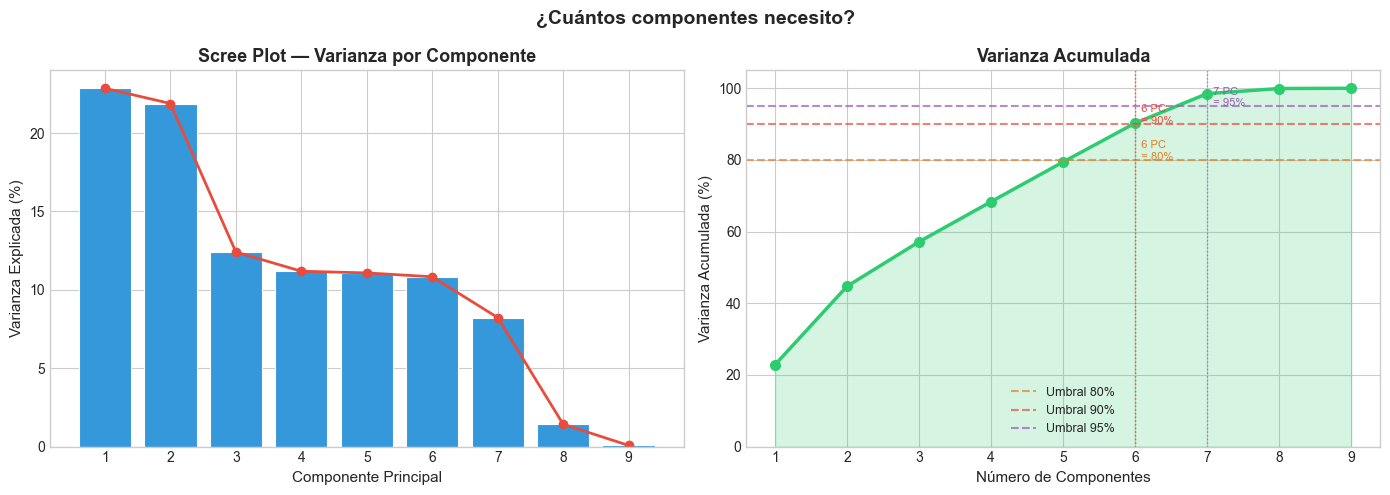

80% varianza → necesito 6 componentes  (de 9 variables originales = 33% reducción)
90% varianza → necesito 6 componentes  (de 9 variables originales = 33% reducción)
95% varianza → necesito 7 componentes  (de 9 variables originales = 22% reducción)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

componentes = range(1, len(NUMERICAS) + 1)

# Panel izquierdo: varianza por componente (Scree Plot)
axes[0].bar(componentes, varianza_explicada * 100, color='#3498db', edgecolor='white', linewidth=0.8)
axes[0].plot(componentes, varianza_explicada * 100, 'o-', color='#e74c3c', lw=2, markersize=6)
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=11)
axes[0].set_title('Scree Plot — Varianza por Componente', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(componentes))

# Panel derecho: varianza acumulada
axes[1].plot(componentes, varianza_acumulada * 100, 'o-', color='#2ecc71', lw=2.5, markersize=7)
axes[1].fill_between(componentes, varianza_acumulada * 100, alpha=0.2, color='#2ecc71')

# Líneas de referencia
for umbral, color, label in [(80, '#e67e22', '80%'), (90, '#e74c3c', '90%'), (95, '#9b59b6', '95%')]:
    axes[1].axhline(umbral, color=color, lw=1.5, linestyle='--', alpha=0.7, label=f'Umbral {label}')
    # Marcar el primer componente que supera el umbral
    n_comp = np.argmax(varianza_acumulada >= umbral/100) + 1
    axes[1].axvline(n_comp, color=color, lw=1, linestyle=':', alpha=0.7)
    axes[1].annotate(f'  {n_comp} PC\n  = {umbral}%',
                     xy=(n_comp, umbral),
                     fontsize=8, color=color)

axes[1].set_xlabel('Número de Componentes', fontsize=11)
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=11)
axes[1].set_title('Varianza Acumulada', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(componentes))
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

plt.suptitle('¿Cuántos componentes necesito?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen
for umbral in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(varianza_acumulada >= umbral) + 1
    reduccion = (1 - n_comp / len(NUMERICAS)) * 100
    print(f'{umbral*100:.0f}% varianza → necesito {n_comp} componentes  '
          f'(de {len(NUMERICAS)} variables originales = {reduccion:.0f}% reducción)')

---
## Sección 5 · Visualización: clientes en 2D

### La magia de PCA: ver datos de 11 dimensiones en 2D

Con PCA podemos proyectar todos los clientes en un plano 2D.  
Aunque perdemos algo de información, ganamos la posibilidad de **ver** los datos.

**¿Qué buscamos?**  
Si los clientes en default (rojo) se separan de los no-default (verde) en el plano, significa que las variables contienen información útil para distinguirlos.

In [27]:
# PCA con 2 componentes para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_scaled)

print(f'Varianza capturada por PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'Varianza capturada por PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total capturado con 2 PCs:  {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

Varianza capturada por PC1: 22.9%
Varianza capturada por PC2: 21.9%
Total capturado con 2 PCs:  44.8%


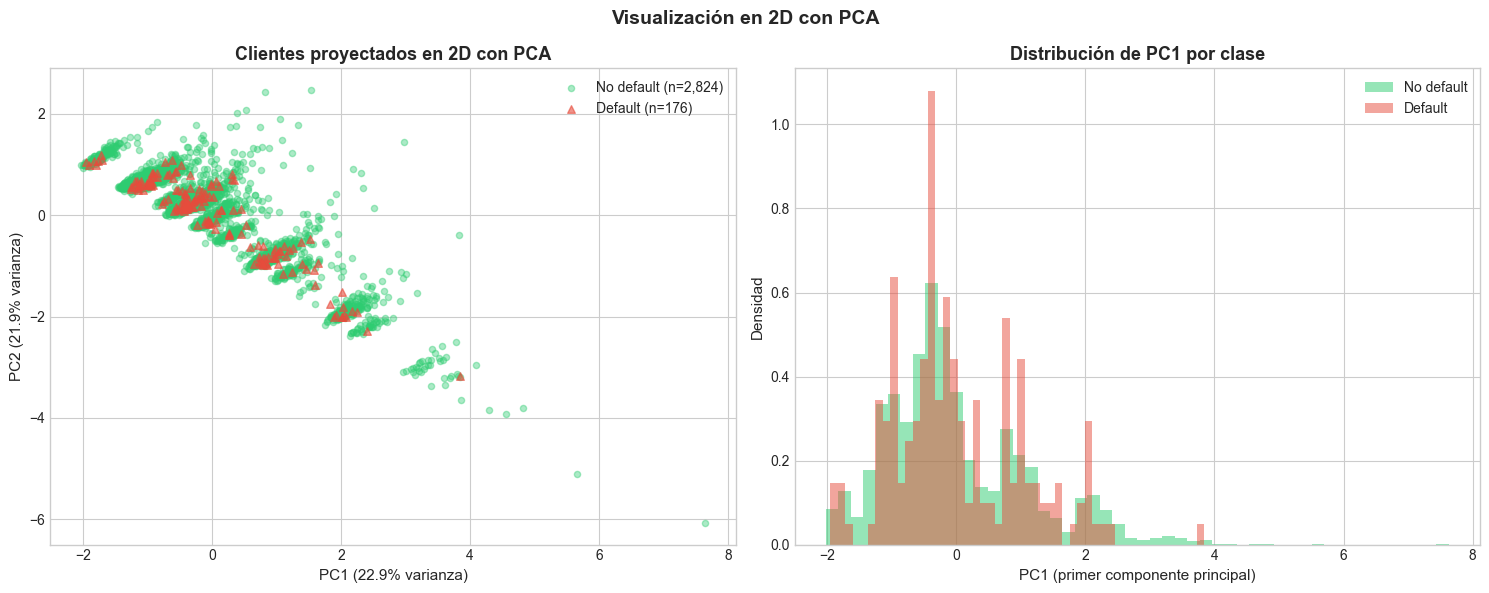

Si los grupos se solapan mucho en 2D, significa que 2 componentes no capturan
suficiente información para separar las clases. Necesitaríamos más componentes.


In [28]:
# Para graficar sin saturar, tomamos una muestra aleatoria
n_muestra   = min(3000, len(y))
idx_muestra = np.random.choice(len(y), n_muestra, replace=False)

X_plot = X_2d[idx_muestra]
y_plot = y.iloc[idx_muestra].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: scatter por default
colors = np.where(y_plot == 1, '#e74c3c', '#2ecc71')
alphas = np.where(y_plot == 1, 0.7, 0.3)

for label, color, marker, nombre in [(0, '#2ecc71', 'o', 'No default'), (1, '#e74c3c', '^', 'Default')]:
    mask = y_plot == label
    axes[0].scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        c=color, marker=marker,
        alpha=0.4 if label == 0 else 0.6,
        s=20 if label == 0 else 30,
        label=f'{nombre} (n={mask.sum():,})'
    )

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
axes[0].set_title('Clientes proyectados en 2D con PCA', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Panel derecho: densidad de PC1 por clase
for label, color, nombre in [(0, '#2ecc71', 'No default'), (1, '#e74c3c', 'Default')]:
    mask = y_plot == label
    axes[1].hist(X_plot[mask, 0], bins=50, alpha=0.5, color=color,
                 label=nombre, density=True)

axes[1].set_xlabel('PC1 (primer componente principal)', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)
axes[1].set_title('Distribución de PC1 por clase', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Visualización en 2D con PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Si los grupos se solapan mucho en 2D, significa que 2 componentes no capturan')
print('suficiente información para separar las clases. Necesitaríamos más componentes.')

---
## Sección 6 · Interpretación de componentes

### ¿Qué significa cada componente principal?

Cada componente principal es una **combinación lineal** de las variables originales.  
Los **loadings** (cargas) nos dicen cuánto contribuye cada variable original a cada componente.

- **Loading alto positivo** → esa variable mueve el componente hacia arriba
- **Loading alto negativo** → esa variable mueve el componente hacia abajo
- **Loading cercano a 0** → esa variable no aporta a ese componente

**Analogía:** Si PC1 tiene cargas altas en `credit_limit` y `net_yearly_income`, podríamos llamarlo "poder adquisitivo" — porque combina variables que miden capacidad económica.

In [29]:
# Extraer los loadings de los primeros 4 componentes
n_pcs_mostrar = min(4, len(NUMERICAS))
loadings = pd.DataFrame(
    pca_full.components_[:n_pcs_mostrar].T,
    index=NUMERICAS,
    columns=[f'PC{i+1}' for i in range(n_pcs_mostrar)]
)

print('Loadings (cargas) de los primeros componentes:')
print('Valores cercanos a ±1 indican alta influencia en ese componente')
print()
print(loadings.round(3).to_string())

Loadings (cargas) de los primeros componentes:
Valores cercanos a ±1 indican alta influencia en ese componente

                        PC1    PC2    PC3    PC4
age                  -0.006  0.014 -0.007 -0.548
no_of_children        0.490 -0.425 -0.263  0.026
net_yearly_income     0.446  0.543 -0.035  0.025
no_of_days_employed  -0.282  0.195 -0.533  0.039
total_family_members  0.494 -0.423 -0.248  0.006
migrant_worker        0.131 -0.109  0.704  0.044
yearly_debt_payments  0.143  0.016  0.274 -0.320
credit_limit          0.446  0.543 -0.037  0.026
credit_limit_used(%)  0.012 -0.006  0.109  0.769


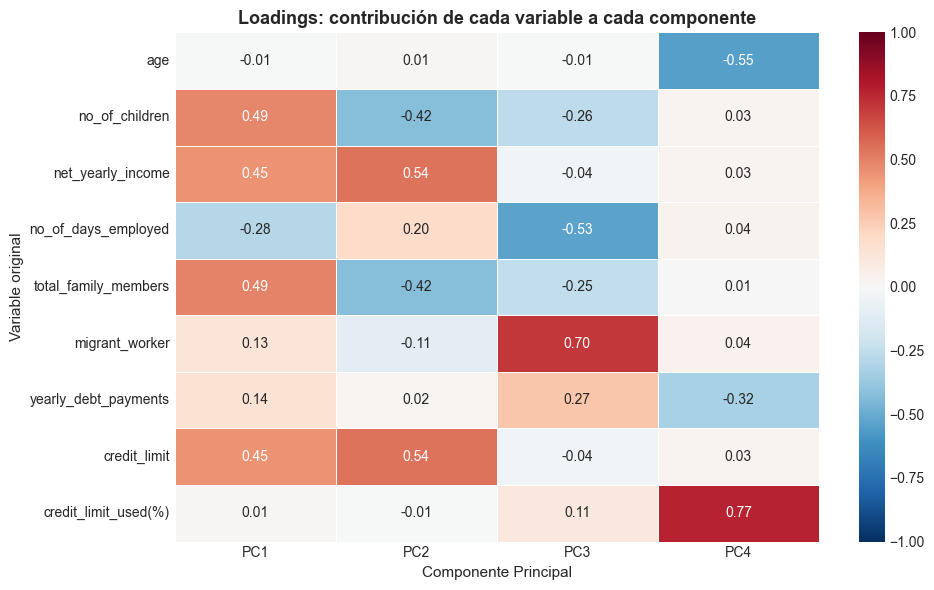

In [30]:
# Heatmap de loadings — visualización más intuitiva
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    loadings,
    annot=True, fmt='.2f',
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Loadings: contribución de cada variable a cada componente',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente Principal', fontsize=11)
ax.set_ylabel('Variable original', fontsize=11)
plt.tight_layout()
plt.show()

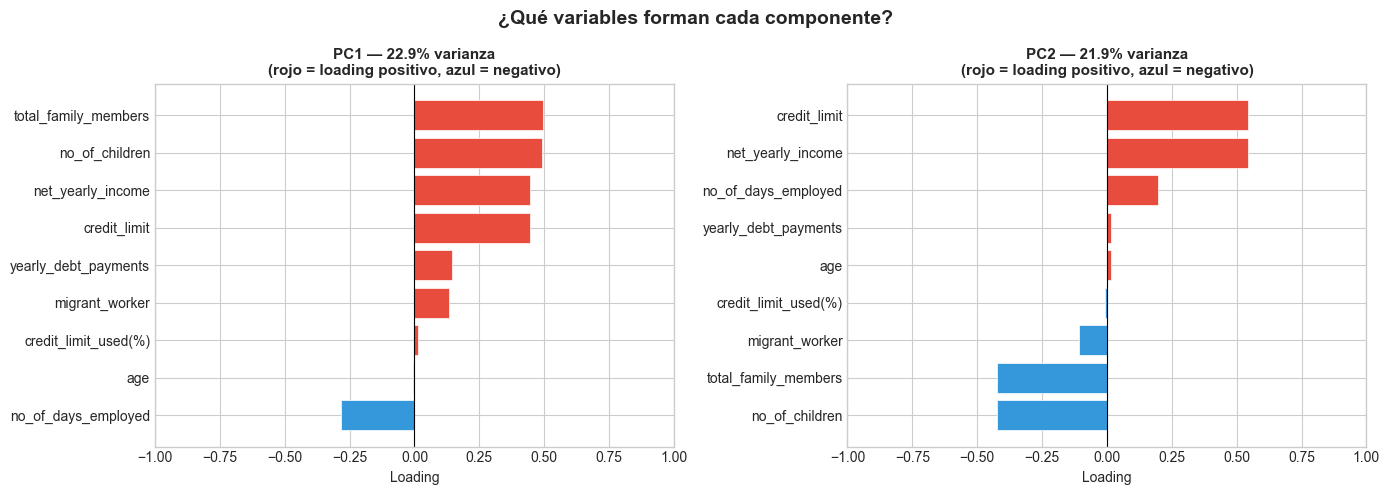


PC1:
  Impulsado por (positivo): total_family_members, no_of_children, net_yearly_income
  Reducido por  (negativo): no_of_days_employed, age, credit_limit_used(%)

PC2:
  Impulsado por (positivo): credit_limit, net_yearly_income, no_of_days_employed
  Reducido por  (negativo): no_of_children, total_family_members, migrant_worker


In [31]:
# Gráfico de barras para PC1 y PC2 — más fácil de leer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    pc_name = f'PC{i+1}'
    vals    = loadings[pc_name].sort_values()
    colors  = ['#e74c3c' if v > 0 else '#3498db' for v in vals]

    ax.barh(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(
        f'{pc_name} — {pca_full.explained_variance_ratio_[i]*100:.1f}% varianza\n'
        f'(rojo = loading positivo, azul = negativo)',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Loading', fontsize=10)
    ax.set_xlim(-1, 1)

plt.suptitle('¿Qué variables forman cada componente?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Descripción de PC1 y PC2
for pc in ['PC1', 'PC2']:
    top_pos = loadings[pc].nlargest(3).index.tolist()
    top_neg = loadings[pc].nsmallest(3).index.tolist()
    print(f'\n{pc}:')
    print(f'  Impulsado por (positivo): {", ".join(top_pos)}')
    print(f'  Reducido por  (negativo): {", ".join(top_neg)}')

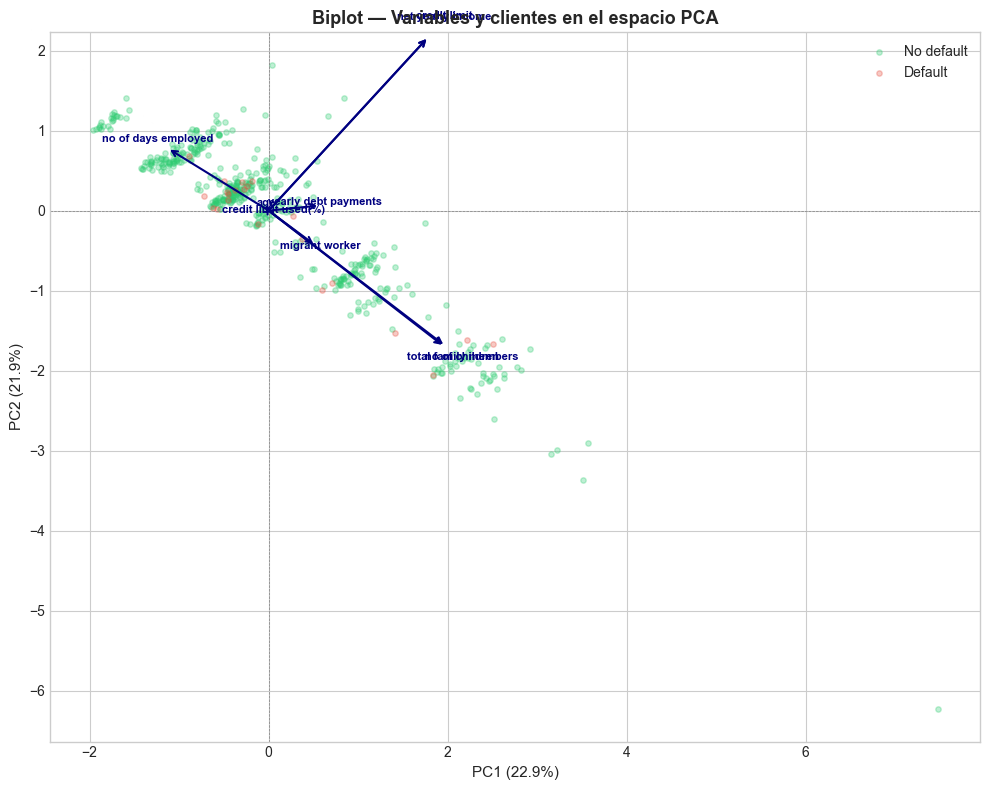

Las flechas apuntan en la dirección en que esa variable crece.
Flechas en la misma dirección = variables correlacionadas.
Flechas perpendiculares = variables independientes.
Flechas opuestas = variables correlacionadas negativamente.


In [32]:
# Biplot: variables y observaciones en el mismo espacio 2D
# Muestra la dirección de cada variable original en el espacio de PC1-PC2

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter de observaciones (muestra pequeña para claridad)
n_bi = min(500, len(y))
idx_bi = np.random.choice(len(y), n_bi, replace=False)

for label, color, nombre in [(0, '#2ecc71', 'No default'), (1, '#e74c3c', 'Default')]:
    mask = y.iloc[idx_bi].values == label
    ax.scatter(
        X_2d[idx_bi][mask, 0], X_2d[idx_bi][mask, 1],
        c=color, alpha=0.3, s=15, label=nombre
    )

# Flechas de las variables originales
escala = 4  # escalar las flechas para que sean visibles
for j, var in enumerate(NUMERICAS):
    ax.annotate(
        '', 
        xy=(pca_2d.components_[0, j] * escala,
            pca_2d.components_[1, j] * escala),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='navy', lw=1.5)
    )
    ax.text(
        pca_2d.components_[0, j] * escala * 1.1,
        pca_2d.components_[1, j] * escala * 1.1,
        var.replace('_', ' '),
        fontsize=8, color='navy', fontweight='bold',
        ha='center'
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('Biplot — Variables y clientes en el espacio PCA',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
plt.tight_layout()
plt.show()

print('Las flechas apuntan en la dirección en que esa variable crece.')
print('Flechas en la misma dirección = variables correlacionadas.')
print('Flechas perpendiculares = variables independientes.')
print('Flechas opuestas = variables correlacionadas negativamente.')

---
## Sección 7 · PCA como preprocesamiento para Regresión Logística

### ¿Vale la pena usar PCA antes de un modelo?

Esta es la pregunta práctica más importante.  
Comparamos tres enfoques:

1. **Sin PCA**: usar todas las variables numéricas directamente
2. **PCA 80%**: usar solo los componentes que explican el 80% de la varianza
3. **PCA 95%**: usar los componentes que explican el 95% de la varianza

Métrica de comparación: **AUC** (mayor = mejor)

In [33]:
from sklearn.model_selection import train_test_split

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Default en train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%')

Train: 36,422  |  Test: 9,106
Default en train: 5.1%  |  Test: 5.1%


In [34]:
resultados = []

# ── Enfoque 1: Sin PCA ──────────────────────────────────────────────────────
logit_base = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logit_base.fit(X_train, y_train)
proba_base = logit_base.predict_proba(X_test)[:, 1]
auc_base   = roc_auc_score(y_test, proba_base)
resultados.append({'Enfoque': f'Sin PCA ({len(NUMERICAS)} variables)', 'N_componentes': len(NUMERICAS), 'AUC': auc_base})

# ── Enfoques con PCA ────────────────────────────────────────────────────────
for umbral in [0.70, 0.80, 0.90, 0.95]:
    # Fit PCA solo en train (mismo principio que el scaler)
    pca_tmp = PCA(n_components=umbral, random_state=42)
    X_tr_pca = pca_tmp.fit_transform(X_train)
    X_te_pca = pca_tmp.transform(X_test)
    
    n_comp = pca_tmp.n_components_
    
    logit_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    logit_pca.fit(X_tr_pca, y_train)
    proba_pca = logit_pca.predict_proba(X_te_pca)[:, 1]
    auc_pca   = roc_auc_score(y_test, proba_pca)
    
    resultados.append({
        'Enfoque': f'PCA {umbral*100:.0f}% varianza ({n_comp} PCs)',
        'N_componentes': n_comp,
        'AUC': auc_pca
    })

df_resultados = pd.DataFrame(resultados)
df_resultados['AUC'] = df_resultados['AUC'].round(4)
df_resultados['Gini'] = (2 * df_resultados['AUC'] - 1).round(4)
df_resultados['vs_base'] = (df_resultados['AUC'] - auc_base).round(4)

print(df_resultados.to_string(index=False))

                 Enfoque  N_componentes    AUC   Gini  vs_base
   Sin PCA (9 variables)              9 0.8459 0.6918  -0.0000
PCA 70% varianza (5 PCs)              5 0.8180 0.6360  -0.0279
PCA 80% varianza (5 PCs)              5 0.8180 0.6360  -0.0279
PCA 90% varianza (6 PCs)              6 0.8456 0.6912  -0.0003
PCA 95% varianza (7 PCs)              7 0.8456 0.6912  -0.0003


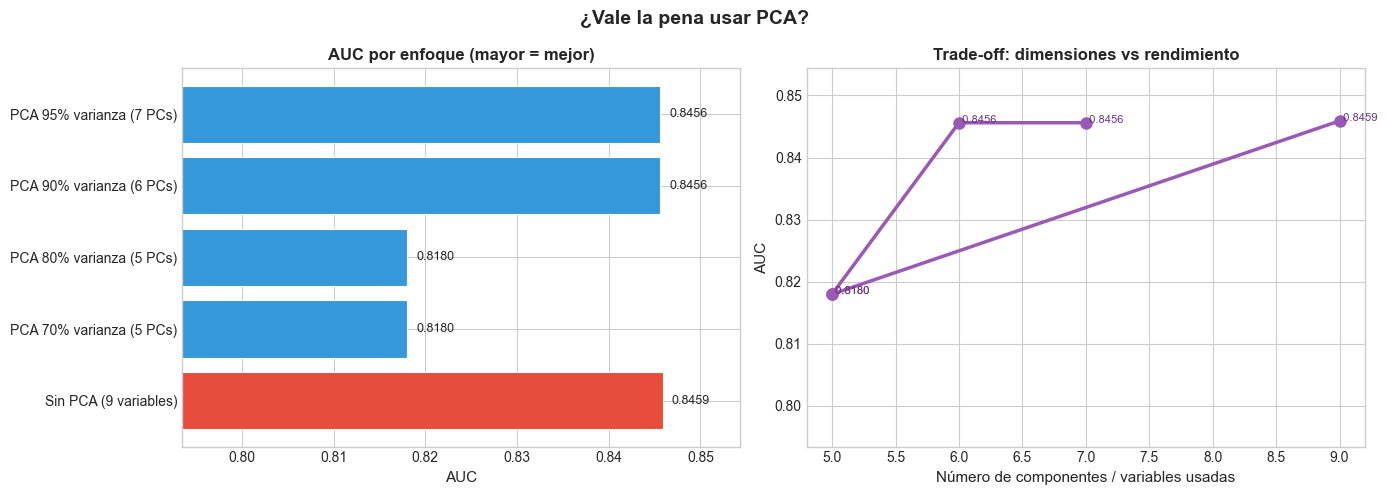

Mejor enfoque: Sin PCA (9 variables)  →  AUC = 0.8459


In [35]:
# Visualización del trade-off: dimensiones vs AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: AUC por enfoque
colores_barras = ['#e74c3c' if e.startswith('Sin') else '#3498db' for e in df_resultados['Enfoque']]
bars = axes[0].barh(
    df_resultados['Enfoque'],
    df_resultados['AUC'],
    color=colores_barras,
    edgecolor='white', linewidth=0.8
)
axes[0].set_xlim(df_resultados['AUC'].min() * 0.97, df_resultados['AUC'].max() * 1.01)
for bar, auc in zip(bars, df_resultados['AUC']):
    axes[0].text(auc + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{auc:.4f}', va='center', fontsize=9)
axes[0].set_xlabel('AUC', fontsize=11)
axes[0].set_title('AUC por enfoque (mayor = mejor)', fontsize=12, fontweight='bold')

# Panel derecho: trade-off componentes vs AUC
axes[1].plot(
    df_resultados['N_componentes'],
    df_resultados['AUC'],
    'o-', color='#9b59b6', lw=2.5, markersize=8
)
for _, row in df_resultados.iterrows():
    axes[1].annotate(
        f" {row['AUC']:.4f}",
        xy=(row['N_componentes'], row['AUC']),
        fontsize=8, color='#6c3483'
    )
axes[1].set_xlabel('Número de componentes / variables usadas', fontsize=11)
axes[1].set_ylabel('AUC', fontsize=11)
axes[1].set_title('Trade-off: dimensiones vs rendimiento', fontsize=12, fontweight='bold')
axes[1].set_ylim(df_resultados['AUC'].min() * 0.97, df_resultados['AUC'].max() * 1.01)

plt.suptitle('¿Vale la pena usar PCA?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mejor = df_resultados.loc[df_resultados['AUC'].idxmax()]
print(f'Mejor enfoque: {mejor["Enfoque"]}  →  AUC = {mejor["AUC"]:.4f}')

---
## Sección 8 · Conclusiones

### ¿Qué aprendimos?

| Concepto | Resumen |
|----------|--------|
| **Qué hace PCA** | Combina variables correlacionadas en componentes independientes, ordenados por varianza |
| **Escalado obligatorio** | Sin StandardScaler, PCA le da más peso a variables con números grandes |
| **Scree plot** | Muestra cuánta información captura cada componente adicional |
| **Loadings** | Explican qué variables forman cada componente y en qué dirección |
| **Biplot** | Visualiza variables y observaciones juntos en 2D |
| **PCA para modelos** | Puede reducir dimensiones sin perder mucho AUC — evaluar siempre el trade-off |

---

### Cuándo usar PCA y cuándo no

**Usar PCA cuando:**
- Tienes muchas variables correlacionadas entre sí
- Necesitas visualizar datos en 2D o 3D
- El modelo tarda mucho y quieres reducir dimensiones
- Hay ruido en los datos que quieres filtrar

**No usar PCA cuando:**
- Necesitas interpretar coeficientes directamente (los componentes no tienen nombre intuitivo)
- Las variables no están correlacionadas (PCA no ayuda)
- Tienes pocas variables y el modelo ya funciona bien
- La reducción de AUC es inaceptable para el negocio

---

### Frase clave

> **"PCA no elimina variables — las transforma. Cambia coordenadas complicadas por coordenadas simples que capturan la misma información."**

In [36]:
# Resumen ejecutivo final
print('=' * 60)
print('  RESUMEN EJECUTIVO — PCA en Riesgo Crediticio')
print('=' * 60)
print(f'  Dataset:           train.csv ({len(df):,} clientes)')
print(f'  Variables entrada: {len(NUMERICAS)} numéricas')
print()

for umbral in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(varianza_acumulada >= umbral) + 1
    reduccion = (1 - n_comp / len(NUMERICAS)) * 100
    print(f'  {umbral*100:.0f}% varianza  →  {n_comp} PCs  (reducción: {reduccion:.0f}%)')

print()
print('  AUC comparado:')
for _, row in df_resultados.iterrows():
    diff_str = f"  ({row['vs_base']:+.4f} vs base)" if row['vs_base'] != 0 else '  (baseline)'
    print(f"  {row['Enfoque']:45s}  AUC = {row['AUC']:.4f}{diff_str}")

print()
print('  Conclusión:')
mejor_pca = df_resultados[df_resultados['Enfoque'].str.startswith('PCA')].loc[
    df_resultados[df_resultados['Enfoque'].str.startswith('PCA')]['AUC'].idxmax()
]
print(f'  El mejor enfoque PCA usa {int(mejor_pca["N_componentes"])} componentes')
print(f'  y obtiene AUC = {mejor_pca["AUC"]:.4f} vs {auc_base:.4f} sin PCA.')
print('=' * 60)

  RESUMEN EJECUTIVO — PCA en Riesgo Crediticio
  Dataset:           train.csv (45,528 clientes)
  Variables entrada: 9 numéricas

  80% varianza  →  6 PCs  (reducción: 33%)
  90% varianza  →  6 PCs  (reducción: 33%)
  95% varianza  →  7 PCs  (reducción: 22%)

  AUC comparado:
  Sin PCA (9 variables)                          AUC = 0.8459  (baseline)
  PCA 70% varianza (5 PCs)                       AUC = 0.8180  (-0.0279 vs base)
  PCA 80% varianza (5 PCs)                       AUC = 0.8180  (-0.0279 vs base)
  PCA 90% varianza (6 PCs)                       AUC = 0.8456  (-0.0003 vs base)
  PCA 95% varianza (7 PCs)                       AUC = 0.8456  (-0.0003 vs base)

  Conclusión:
  El mejor enfoque PCA usa 6 componentes
  y obtiene AUC = 0.8456 vs 0.8459 sin PCA.
